## XGBoost를 활용한 주식 가격 예측

In [172]:
import pandas as pd
import numpy as np
import yfinance as yf

### 1. 종목, 기간 설정

In [173]:
# 엔비디아, TSMC, Broadcom, ASML, AMD
symbols = ["NVDA", "TSM", "AVGO", "ASML", "AMD"] 

all_data = []

start = "2023-01-01"
end = "2024-07-01"

### 2. 피처 엔지니어링 : MACD, 볼린저밴드, RSI

In [174]:
# MACD 계산 함수
def add_macd(df, short_window=12, long_window=26, signal_window=9):
    df['EMA12'] = df['Close'].ewm(span=short_window, adjust=False).mean()
    df['EMA26'] = df['Close'].ewm(span=long_window, adjust=False).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['Signal_Line'] = df['MACD'].ewm(span=signal_window, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['Signal_Line']
    return df

# 볼린저 밴드 계산 함수
def add_bollinger_bands(df, window=20):
    df['MA20'] = df['Close'].rolling(window=window).mean()
    df['BB_upper'] = df['MA20'] + 2 * df['Close'].rolling(window=window).std()
    df['BB_lower'] = df['MA20'] - 2 * df['Close'].rolling(window=window).std()
    df['BB_width'] = df['BB_upper'] - df['BB_lower']
    return df

# RSI 계산 함수
def add_rsi(df, window=14):
    delta = df['Close'].diff(1)
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)

    avg_gain = pd.Series(gain).rolling(window=window, min_periods=1).mean()
    avg_loss = pd.Series(loss).rolling(window=window, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = np.where(avg_loss == 0, 100, 100 - (100 / (1 + rs)))
    return df

### 3. 데이터 전처리

In [175]:
from sklearn.preprocessing import MinMaxScaler

for symbol in symbols:
    df = yf.download(symbol, start, end)

    df = add_macd(df)
    df = add_bollinger_bands(df)
    df = add_rsi(df)
    
    # 타겟 생성 (다음 날의 주가 상승 여부)
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    
    df = df.fillna(method='ffill').dropna()
    
    # 날짜 인덱스가 시간 순서대로 정렬되었는지 확인 및 정렬
    df = df.sort_index()

    # columns 정의
    scale_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MACD', 'Signal_Line', 'MACD_Hist', 'MA20', 'BB_upper', 'BB_lower', 'BB_width', 'RSI']
    
    # 스케일링
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[scale_cols])
    scaled_df = pd.DataFrame(scaled, columns=scale_cols, index=df.index)
    
    # 스케일된 데이터와 타겟 결합
    scaled_df['Target'] = df['Target'].values
    all_data.append(scaled_df)

data = pd.concat(all_data, axis=0, ignore_index=False)

# 인덱스가 datetime 형식인지 확인 및 변환
data.index = pd.to_datetime(data.index)
# 날짜가 시간 순서대로 정렬되어 있는지 확인
data = data.sort_index()


[*********************100%***********************]  1 of 1 completed
C:\TempFolder\ipykernel_22720\232799144.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').dropna()
[*********************100%***********************]  1 of 1 completed
C:\TempFolder\ipykernel_22720\232799144.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').dropna()
[*********************100%***********************]  1 of 1 completed
C:\TempFolder\ipykernel_22720\232799144.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').dropna()
[*********************100%***********************]  1 of 1 completed
C:\TempFolder\ipykernel_22720\232799144.py:13: Fu

### 4. 데이터셋 분리

In [176]:
# 시간 기반으로 훈련 및 테스트 데이터 분할
train_data = data.loc['2023-01-01':'2024-12-31']  # 훈련 데이터
test_data = data.loc['2024-01-01':'2024-07-01']   # 테스트 데이터

# 독립 변수(X)와 종속 변수(y) 설정
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']
X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

### 5. XGBoost 모델

In [177]:
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBClassifier

# 그리드 서치에 사용할 하이퍼파라미터 그리드 정의
param_grid = {
    'n_estimators': [35, 40, 45],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.008, 0.01, 0.02],
    'subsample': [0.9, 0.95],
    'colsample_bytree': [0.85, 0.9, 0.95],
    'gamma': [0.25, 0.3, 0.35],
    'min_child_weight': [1]
}

xgb = XGBClassifier(eval_metric='logloss')

xgboost = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',  # 모델 성능을 평가할 지표 (필요에 따라 변경 가능)
    cv=KFold(n_splits = 3),  # 교차 검증 폴드 수
    n_jobs=-1  # 병렬 처리 사용 (모든 프로세서 사용)
)
# 그리드 서치 실행 (훈련 데이터를 사용)
xgboost.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=3, random_state=None, shuffle=False),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.85, 0.9, 0.95],
                         'gamma': [0.25, 0.3, 0.35],
                         'learning_rate': [0.008, 0.01, 0.02],
                         'max_depth': [3, 4, 5], 'min_child_weight': [1],
                         'n_estimators': [35, 40, 45],
                         'subsample': [0.9, 0.95]},
             scoring='accuracy')

### 6. 평가

In [187]:
# 최적의 하이퍼파라미터 출력
print("Best parameters found: ", xgboost.best_params_)
print("Best Accuracy: {:.1f}%".format(xgboost.best_score_ * 100))

Best parameters found:  {'colsample_bytree': 0.95, 'gamma': 0.25, 'learning_rate': 0.008, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 35, 'subsample': 0.95}
Best Accuracy: 53.3%


In [186]:
y_pred = xgboost.predict(X_test)

# 초기 투자금 설정
initial_investment = 1000000  # 100만 원

investment = initial_investment
holding = False  # 현재 주식을 보유 중인지 여부
num_shares = 0   # 구매한 주식 수

X_test['Close'] = test_data['Close']

# 각 날의 수익률을 계산
for i in range(len(y_test) - 1):
    if y_pred[i] == 1 and not holding:  # 상승 예측 & 주식을 보유하지 않은 경우 매수
        # 전날 종가로 매수
        num_shares = investment / X_test['Close'].iloc[i]
        holding = True
    
    elif y_pred[i] == 0 and holding:  # 하락 예측 & 주식을 보유한 경우 매도
        # 오늘 종가로 매도
        investment = num_shares * X_test['Close'].iloc[i]
        holding = False
        num_shares = 0

if holding:
    investment = num_shares * X_test['Close'].iloc[-1]

# 최종 수익률 계산
final_profit = (investment - initial_investment) / initial_investment * 100

print(f"최종 투자 금액: {investment:.2f}원")
print(f"최종 수익률: {final_profit:.2f}%")

최종 투자 금액: 828102.25원
최종 수익률: -17.19%


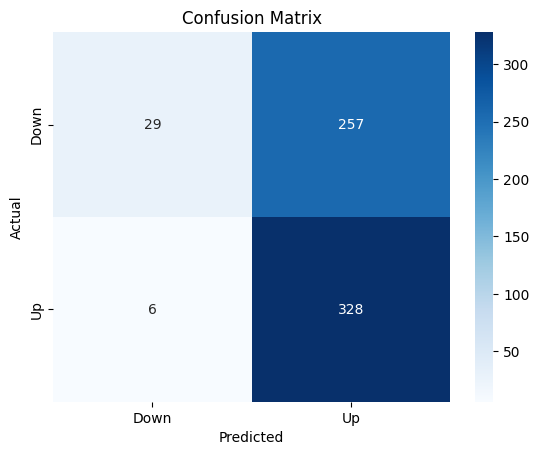

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 테스트 데이터를 사용하여 예측
y_pred = xgboost.predict(X_test)

# 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 혼동 행렬 시각화
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [181]:
# 상관계수 행렬
correlation_matrix = data.corr()
top_3_features = correlation_matrix['Target'].sort_values(ascending=False).index[1:4]
top_3_features

Index(['Volume', 'BB_lower', 'MA20'], dtype='object')

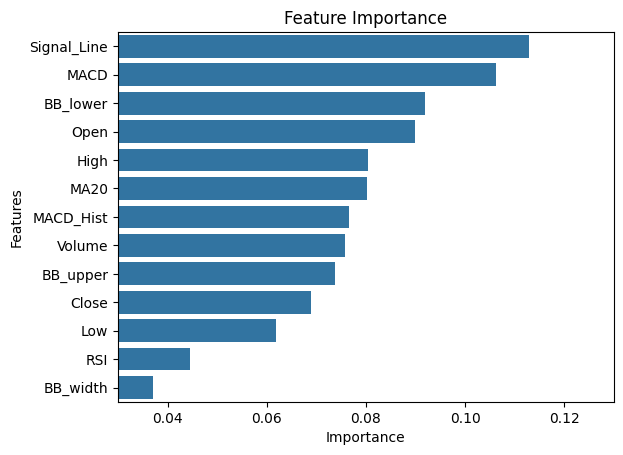

In [182]:
# 피처 중요도 추출
importances = xgboost.best_estimator_.feature_importances_

# 피처 중요도를 시각화
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.xlim(0.03, 0.13)
plt.show()


### 7. 다른 주식에 적용

In [183]:
# 테스트할 종목 리스트
test_symbols = ['KLAC', 'MRVL', 'MPWR', 'MCHP', 'ON']

# 정확도를 저장할 딕셔너리
accuracy_dict = {}

for symbol in test_symbols:

    test_data = yf.download(symbol, start=start, end=end)
    
    test_data = add_macd(test_data)
    test_data = add_bollinger_bands(test_data)
    test_data = add_rsi(test_data)
    
    test_data['Target'] = (test_data['Close'].shift(-1) > test_data['Close']).astype(int)
    
    test_data = test_data.fillna(method='ffill').dropna()
    test_data = test_data.sort_index()
    
    scaled = scaler.transform(test_data[scale_cols])
    scaled_df = pd.DataFrame(scaled, columns=scale_cols, index=test_data.index)
    scaled_df['Target'] = test_data['Target'].values
    
    X_test_symbol = scaled_df.drop(columns=['Target'])
    y_test_symbol = scaled_df['Target']
    
    y_pred_symbol = xgboost.predict(X_test_symbol)
    
    accuracy = accuracy_score(y_test_symbol, y_pred_symbol)
    accuracy_dict[symbol] = accuracy

# 정확도 딕셔너리를 DataFrame으로 변환
accuracy_df = pd.DataFrame(list(accuracy_dict.items()), columns=['Symbol', 'Accuracy'])

[*********************100%***********************]  1 of 1 completed
C:\TempFolder\ipykernel_22720\4251811678.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_data = test_data.fillna(method='ffill').dropna()
[*********************100%***********************]  1 of 1 completed
C:\TempFolder\ipykernel_22720\4251811678.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_data = test_data.fillna(method='ffill').dropna()
[*********************100%***********************]  1 of 1 completed
C:\TempFolder\ipykernel_22720\4251811678.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_data = test_data.fillna(method='ffill').dropna()
[*********************100%***********************]  1 of 1 completed
C:\T

In [184]:
accuracy_df

,Symbol,Accuracy
0,KLAC,0.512676
1,MRVL,0.521127
2,MPWR,0.529577
3,MCHP,0.507042
4,ON,0.498592


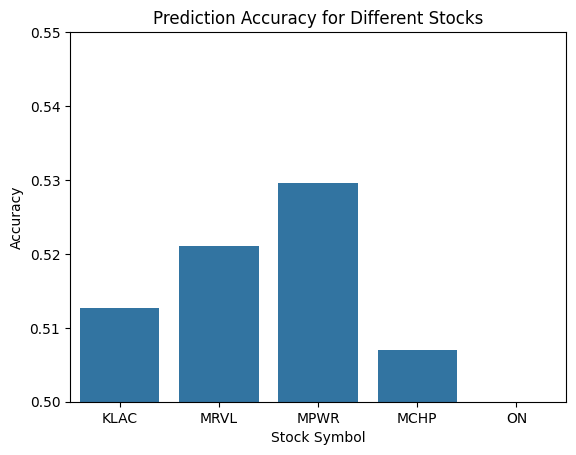

In [185]:
sns.barplot(x='Symbol', y='Accuracy', data=accuracy_df)
plt.title('Prediction Accuracy for Different Stocks')
plt.xlabel('Stock Symbol')
plt.ylabel('Accuracy')
plt.ylim(0.5, 0.55)
plt.show()